# **Covid 19 prediction for 10 years**

**Problématique :** Prédire l'évolution du nombre de nouveaux cas quotidiens de COVID-19 sur un horizon de 10 ans, à partir des données historiques mondiales (2020-2024), en utilisant un pipeline Big Data Spark et des modèles de régression MLlib.
Zone choisie : Maroc

In [ ]:
# Installation de Spark sur Colab
!pip install pyspark -q

In [ ]:
# Setup Spark
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("CovidPredictionMLlib") \
    .config("spark.sql.shuffle.partitions", "4") \
    .getOrCreate()

spark

In [ ]:
# On donne a colab l'autorisation de  voir l'interieur de notre drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# On Verifie si le fichier du dataset est bien present
!ls "/content/drive/MyDrive/Colab Notebooks/covid-spark-project/"

owid-covid-data.csv


In [ ]:
# Charger le dataset en DataFrame Spark
df= spark.read.csv(
    "/content/drive/MyDrive/Colab Notebooks/covid-spark-project/",
    header=True,
    inferSchema=True
)

print("Nombre de lignes: ", df.count())
print("Nombre de colonnes: ", len(df.columns))
df.printSchema()

Nombre de lignes:  429435
Nombre de colonnes:  67
root
 |-- iso_code: string (nullable = true)
 |-- continent: string (nullable = true)
 |-- location: string (nullable = true)
 |-- date: date (nullable = true)
 |-- total_cases: integer (nullable = true)
 |-- new_cases: integer (nullable = true)
 |-- new_cases_smoothed: double (nullable = true)
 |-- total_deaths: integer (nullable = true)
 |-- new_deaths: integer (nullable = true)
 |-- new_deaths_smoothed: double (nullable = true)
 |-- total_cases_per_million: double (nullable = true)
 |-- new_cases_per_million: double (nullable = true)
 |-- new_cases_smoothed_per_million: double (nullable = true)
 |-- total_deaths_per_million: double (nullable = true)
 |-- new_deaths_per_million: double (nullable = true)
 |-- new_deaths_smoothed_per_million: double (nullable = true)
 |-- reproduction_rate: double (nullable = true)
 |-- icu_patients: integer (nullable = true)
 |-- icu_patients_per_million: double (nullable = true)
 |-- hosp_patients: in

In [ ]:
# Filtrer sur le Maroc
from pyspark.sql.functions import col, when, to_date, min as spark_min, max as spark_max

# Colonnes utiles

colonnes_utiles = ["date", "location", "new_cases", "new_deaths", "total_cases", "total_deaths"]

df_clean = df.select(colonnes_utiles).filter(col("location") == "Morocco")

# Suppression des lignes sans variable cible
df_clean = df_clean.na.drop(subset=["new_cases"])

# Correction des valeurs négatives (artefacts de correction de données)
df_clean = df_clean.withColumn(
    "new_cases",
    when(col("new_cases") < 0, 0).otherwise(col("new_cases"))
)

# Conversion de la date + tri chronologique
df_clean = df_clean.withColumn("date", to_date(col("date"), "yyyy-MM-dd"))
df_clean = df_clean.orderBy("date")

print("Nombre de lignes après nettoyage :", df_clean.count())
df_clean.select(
    spark_min("date").alias("date_debut"),
    spark_max("date").alias("date_fin")
).show()

Nombre de lignes après nettoyage : 1674
+----------+----------+
|date_debut|  date_fin|
+----------+----------+
|2020-01-05|2024-08-04|
+----------+----------+



In [ ]:
#EXPLORATION : describe()
df_clean.describe(["new_cases", "new_deaths", "total_cases", "total_deaths"]).show()

+-------+-----------------+------------------+------------------+-----------------+
|summary|        new_cases|        new_deaths|       total_cases|     total_deaths|
+-------+-----------------+------------------+------------------+-----------------+
|  count|             1674|              1674|              1674|             1674|
|   mean|764.1069295101553| 9.740143369175627| 868960.9599761051|11828.44145758662|
| stddev|4615.808737369419|57.832714018438935|488072.92477802583|6083.332762619096|
|    min|                0|                 0|                 0|                0|
|    max|            64784|               744|           1279115|            16305|
+-------+-----------------+------------------+------------------+-----------------+



In [ ]:
# Moyenne mensuelle de new_cases
from pyspark.sql.functions import month, year, avg

df_mensuel = df_clean.groupBy(year("date").alias("year"), month("date").alias("month")).agg(
    avg("new_cases").alias("avg_new_cases")
).orderBy("year", "month")

df_mensuel.show(10)

# Pic par jour (jour avec le plus de nouveaux cas)
df_clean.orderBy(col("new_cases").desc()).select("date", "new_cases").show(5)

+----+-----+------------------+
|year|month|     avg_new_cases|
+----+-----+------------------+
|2020|    1|               0.0|
|2020|    2|               0.0|
|2020|    3|12.580645161290322|
|2020|    4|             116.9|
|2020|    5|125.25806451612904|
|2020|    6|136.56666666666666|
|2020|    7|250.58064516129033|
|2020|    8|1303.5806451612902|
|2020|    9|            1839.5|
|2020|   10| 2555.483870967742|
+----+-----+------------------+
only showing top 10 rows
+----------+---------+
|      date|new_cases|
+----------+---------+
|2021-08-15|    64784|
|2021-08-08|    63764|
|2021-08-22|    54212|
|2022-01-23|    50753|
|2021-08-01|    48366|
+----------+---------+
only showing top 5 rows


In [ ]:
# ============================================================
# AGRÉGATION HEBDOMADAIRE
# (le reporting quotidien devient irrégulier après 2022,
#  on passe donc à une granularité hebdomadaire pour stabiliser le signal)
# ============================================================

from pyspark.sql.functions import weekofyear, sum as spark_sum

df_hebdo = df_clean.withColumn("annee", year("date")) \
    .withColumn("semaine", weekofyear("date")) \
    .groupBy("annee", "semaine") \
    .agg(
        spark_sum("new_cases").alias("new_cases"),
        spark_min("date").alias("date")
    ) \
    .orderBy("date")

print("Nombre de lignes (hebdomadaire) :", df_hebdo.count())

Nombre de lignes (hebdomadaire) : 241


In [ ]:
# FEATURE ENGINEERING - Colonne "jours depuis le début"
from pyspark.sql.functions import datediff, lit, avg, lag, when, month, col, greatest, least, min as spark_min, log1p
from pyspark.sql import Window

# Récupérer la première date du dataset
date_debut = df_hebdo.select(spark_min("date")).collect()[0][0]
# Semaines depuis le début
df_features = df_hebdo.withColumn("semaines_depuis_debut", datediff(col("date"), lit(date_debut)) / 7)

# Moyenne mobile 4 semaines (SANS la semaine actuelle, pour éviter la fuite de données)
window_4s = Window.orderBy("date").rowsBetween(-4, -1)
df_features = df_features.withColumn("moyenne_mobile_4s", avg("new_cases").over(window_4s))

# Taux de croissance semaine à semaine (avec clipping pour éviter les valeurs extrêmes)
window_lag = Window.orderBy("date")
df_features = df_features.withColumn("new_cases_semaine_prec", lag("new_cases", 1).over(window_lag))
df_features = df_features.withColumn(
    "taux_croissance",
    when(
        col("new_cases_semaine_prec").isNotNull() & (col("new_cases_semaine_prec") != 0),
        (col("new_cases") - col("new_cases_semaine_prec")) / col("new_cases_semaine_prec")
    ).otherwise(0)
)
df_features = df_features.withColumn(
    "taux_croissance",
    greatest(lit(-5.0), least(lit(5.0), col("taux_croissance")))
)

# Mois (saisonnalité)
df_features = df_features.withColumn("mois", month(col("date")))

# Nettoyage des nulls générés par les fenêtres
df_features = df_features.na.fill(0, subset=["moyenne_mobile_4s", "new_cases_semaine_prec", "taux_croissance"])

print("Nombre de lignes df_features :", df_features.count())
df_features.filter(col("date") >= "2023-09-01").select("date", "new_cases", "moyenne_mobile_4s", "taux_croissance").show(20)

# Transformation logarithmique de la cible
# (le passage de la phase épidémique 2020-2022, pics à 30-65k/semaine,
#  à la phase endémique 2023-2024, valeurs proches de 0, crée un changement
#  d'échelle de plusieurs ordres de grandeur -> log1p stabilise l'apprentissage)
df_features = df_features.withColumn("new_cases_log", log1p(col("new_cases")))

df_features.select("date", "new_cases", "new_cases_log", "moyenne_mobile_4s", "taux_croissance", "mois").show(10)


Nombre de lignes df_features : 241
+----------+---------+-----------------+--------------------+
|      date|new_cases|moyenne_mobile_4s|     taux_croissance|
+----------+---------+-----------------+--------------------+
|2023-09-04|      312|           142.75|0.009708737864077669|
|2023-09-11|      254|            214.0| -0.1858974358974359|
|2023-09-18|      205|            259.0|-0.19291338582677164|
|2023-09-25|      177|            270.0|-0.13658536585365855|
|2023-10-02|      138|            237.0|-0.22033898305084745|
|2023-10-09|      132|            193.5|-0.04347826086956...|
|2023-10-16|      136|            163.0|0.030303030303030304|
|2023-10-23|      124|           145.75|-0.08823529411764706|
|2023-10-30|        0|            132.5|                -1.0|
|2023-11-06|      196|             98.0|                 0.0|
|2023-11-13|      104|            114.0|-0.46938775510204084|
|2023-11-20|      104|            106.0|                 0.0|
|2023-11-27|      116|            1

In [ ]:
# VECTORASSEMBLER + SPLIT CHRONOLOGIQUE + STANDARDISATION
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.sql.functions import row_number

features_liste = ["semaines_depuis_debut", "moyenne_mobile_4s", "taux_croissance", "mois"]
assembler = VectorAssembler(inputCols=features_liste, outputCol="features")
df_final = assembler.transform(df_features)

# Split chronologique 80/20 (Chronologique vu que c'est une série temporelle)
window_index = Window.orderBy("date")
df_final = df_final.withColumn("index_ligne", row_number().over(window_index))
nb_total = df_final.count()
nb_train = int(nb_total * 0.8)

df_train = df_final.filter(col("index_ligne") <= nb_train)
df_test = df_final.filter(col("index_ligne") > nb_train)

print("Total :", nb_total, " | Train :", df_train.count(), " | Test :", df_test.count())

# Standardisation des features
scaler = StandardScaler(inputCol="features", outputCol="features_scaled", withMean=True, withStd=True)
scaler_model = scaler.fit(df_train)
df_train_scaled = scaler_model.transform(df_train)
df_test_scaled = scaler_model.transform(df_test)

Total : 241  | Train : 192  | Test : 49


# **Creation Pipeline Spark & Entraînement des modèles (LinearRegression et RandomForest Regressor)**

In [ ]:
# creation Pipeline
from pyspark.ml import Pipeline
from pyspark.ml.regression import LinearRegression, RandomForestRegressor

pipeline_lr = Pipeline(stages=[LinearRegression(featuresCol="features_scaled", labelCol="new_cases_log", regParam=0.3, elasticNetParam=0.5)])
pipeline_rf = Pipeline(stages=[RandomForestRegressor(featuresCol="features", labelCol="new_cases_log", numTrees=100, seed=42)])

# Entraînement via le pipeline
modele_pipeline_lr = pipeline_lr.fit(df_train_scaled)
modele_pipeline_rf = pipeline_rf.fit(df_train)

print("Pipelines entraînés avec succès ✅")

Pipelines entraînés avec succès ✅


In [ ]:
# Générer les prédictions avec les pipelines entraînés
from pyspark.sql.functions import lit, when, expm1

pipeline_predictions_lr = modele_pipeline_lr.transform(df_test_scaled).withColumn("prediction_reelle", expm1(col("prediction")))
pipeline_predictions_rf = modele_pipeline_rf.transform(df_test).withColumn("prediction_reelle", expm1(col("prediction")))


pipeline_predictions_lr.select("date", "new_cases", "prediction_reelle").show(10)
pipeline_predictions_rf.select("date", "new_cases", "prediction_reelle").show(10)

+----------+---------+------------------+
|      date|new_cases| prediction_reelle|
+----------+---------+------------------+
|2023-08-21|      161|  524.864691219821|
|2023-08-28|      309| 500.3405750368106|
|2023-09-04|      312| 457.5597505300028|
|2023-09-11|      254| 443.2624225885934|
|2023-09-18|      205| 444.1978341192053|
|2023-09-25|      177|448.95810545051233|
|2023-10-02|      138| 476.6844010132107|
|2023-10-09|      132| 490.2536944874859|
|2023-10-16|      136| 494.8918907742359|
|2023-10-23|      124|481.89465704054396|
+----------+---------+------------------+
only showing top 10 rows
+----------+---------+------------------+
|      date|new_cases| prediction_reelle|
+----------+---------+------------------+
|2023-08-21|      161|57.153260451681575|
|2023-08-28|      309|   70.692120509205|
|2023-09-04|      312| 83.74533994259755|
|2023-09-11|      254|  95.3748328640678|
|2023-09-18|      205|  95.3748328640678|
|2023-09-25|      177|120.58514565699666|
|2023-10-

# **Évaluation des modèles (RMSE, R²)**

In [ ]:
# Calculer le RMSE (Root Mean Squared Error)
from pyspark.ml.evaluation import RegressionEvaluator

evaluator_rmse = RegressionEvaluator(labelCol="new_cases", predictionCol="prediction_reelle", metricName="rmse")

rmse_lr = evaluator_rmse.evaluate(pipeline_predictions_lr)
rmse_rf = evaluator_rmse.evaluate(pipeline_predictions_rf)

print(f"RMSE Régression Linéaire : {rmse_lr:.2f}")
print(f"RMSE Random Forest       : {rmse_rf:.2f}")

RMSE Régression Linéaire : 309.23
RMSE Random Forest       : 67.63


In [ ]:
# Calculer le R² (coefficient de détermination)
evaluator_r2 = RegressionEvaluator(labelCol="new_cases", predictionCol="prediction_reelle", metricName="r2")

r2_lr = evaluator_r2.evaluate(pipeline_predictions_lr)
r2_rf = evaluator_r2.evaluate(pipeline_predictions_rf)

print(f"R² Régression Linéaire : {r2_lr:.3f}")
print(f"R² Random Forest       : {r2_rf:.3f}")

R² Régression Linéaire : -12.455
R² Random Forest       : 0.356


In [ ]:
import pandas as pd

comparaison = pd.DataFrame({
    "Modèle": ["Régression Linéaire", "Random Forest"],
    "RMSE": [rmse_lr, rmse_rf],
    "R²": [r2_lr, r2_rf]
})

print(comparaison)

                Modèle        RMSE         R²
0  Régression Linéaire  309.233382 -12.454893
1        Random Forest   67.627236   0.356497


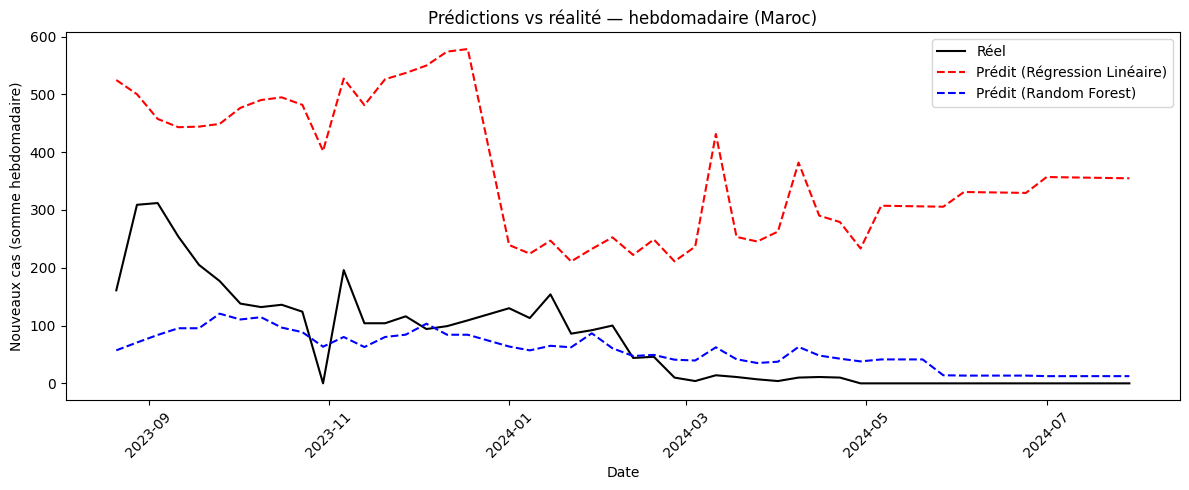

In [ ]:
# Visualisation: Prediction vs realite
import matplotlib.pyplot as plt

# Convertir en Pandas pour la visualisation (dataset de test est petit, donc pas de souci)
pdf_lr = pipeline_predictions_lr.select("date", "new_cases", "prediction_reelle").orderBy("date").toPandas()
pdf_rf = pipeline_predictions_rf.select("date", "new_cases", "prediction_reelle").orderBy("date").toPandas()

plt.figure(figsize=(12, 5))
plt.plot(pdf_lr["date"], pdf_lr["new_cases"], label="Réel", color="black")
plt.plot(pdf_lr["date"], pdf_lr["prediction_reelle"], label="Prédit (Régression Linéaire)", color="red", linestyle="--")
plt.plot(pdf_rf["date"], pdf_rf["prediction_reelle"], label="Prédit (Random Forest)", color="blue", linestyle="--")
plt.legend()
plt.title("Prédictions vs réalité — hebdomadaire (Maroc)")
plt.xlabel("Date")
plt.ylabel("Nouveaux cas (somme hebdomadaire)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **8. Prévision à 10 ans**

In [ ]:
import pandas as pd
from datetime import timedelta

# Récupérer les dernières semaines connues en pandas (pour manipuler facilement l'historique glissant)
historique = df_features.select("date", "new_cases").orderBy("date").toPandas()
historique["date"] = pd.to_datetime(historique["date"])

date_debut_py = historique["date"].min()

print("Dernière date connue :", historique["date"].max())
print("Dernières valeurs connues :")
print(historique.tail(6))

Dernière date connue : 2024-07-29 00:00:00
Dernières valeurs connues :
          date  new_cases
235 2024-06-24          0
236 2024-07-01          0
237 2024-07-08          0
238 2024-07-15          0
239 2024-07-22          0
240 2024-07-29          0


In [ ]:
from pyspark.sql import Row

nb_semaines_futures = 52 * 10  # 10 ans
derniere_date = historique["date"].max()

for i in range(nb_semaines_futures):
    nouvelle_date = derniere_date + timedelta(weeks=1)

    # Calcul des features à partir de l'historique (réel + déjà prédit)
    semaines_depuis_debut = (nouvelle_date - date_debut_py).days / 7

    # Moyenne mobile sur les 4 dernières semaines connues/prédites (sans la semaine courante)
    moyenne_mobile_4s = historique["new_cases"].tail(4).mean()
    # Si la moyenne mobile est NaN (pas assez de données), on la met à 0
    if pd.isna(moyenne_mobile_4s):
        moyenne_mobile_4s = 0.0

    # Taux de croissance par rapport à la semaine précédente
    derniere_valeur = historique["new_cases"].iloc[-1]
    if derniere_valeur != 0:
        # Ici, pour la prévision, nous n'avons pas encore le new_cases de la semaine actuelle
        # Donc, pour une première approximation, on peut assumer un taux de croissance nul ou prendre la dernière connue.
        # Pour cet exemple, on le met à 0, mais une approche plus sophistiquée pourrait réutiliser le taux de croissance précédent.
        taux_croissance = 0.0
    else:
        taux_croissance = 0.0
    taux_croissance = max(-5.0, min(5.0, taux_croissance))

    mois = nouvelle_date.month

    # Construire une ligne Spark à partir de ces features
    ligne_future_raw = spark.createDataFrame([Row(
        semaines_depuis_debut=float(semaines_depuis_debut),
        moyenne_mobile_4s=float(moyenne_mobile_4s),
        taux_croissance=float(taux_croissance),
        mois=int(mois)
    )])

    # Appliquer le VectorAssembler pour créer la colonne 'features'
    # L'objet 'assembler' a été défini dans la cellule 'vhlV0f1PD37F'
    ligne_future_assembled = assembler.transform(ligne_future_raw)

    # Appliquer le pipeline RF (qui s'attend à une colonne 'features')
    prediction_row = modele_pipeline_rf.transform(ligne_future_assembled).select("prediction").collect()[0][0]
    prediction_reelle = max(0, round(float(2.718281828 ** prediction_row - 1)))  # expm1 manuel

    # Ajouter cette prédiction à l'historique pour la suite de la boucle
    historique = pd.concat([
        historique,
        pd.DataFrame([{"date": nouvelle_date, "new_cases": prediction_reelle}])
    ], ignore_index=True)

    derniere_date = nouvelle_date

print("Simulation terminée. Aperçu des dernières semaines prédites :")
print(historique.tail(15))

Simulation terminée. Aperçu des dernières semaines prédites :
          date  new_cases
746 2034-04-10         47
747 2034-04-17         47
748 2034-04-24         47
749 2034-05-01         44
750 2034-05-08         44
751 2034-05-15         44
752 2034-05-22         44
753 2034-05-29         44
754 2034-06-05         40
755 2034-06-12         40
756 2034-06-19         40
757 2034-06-26         40
758 2034-07-03         36
759 2034-07-10         34
760 2034-07-17         34


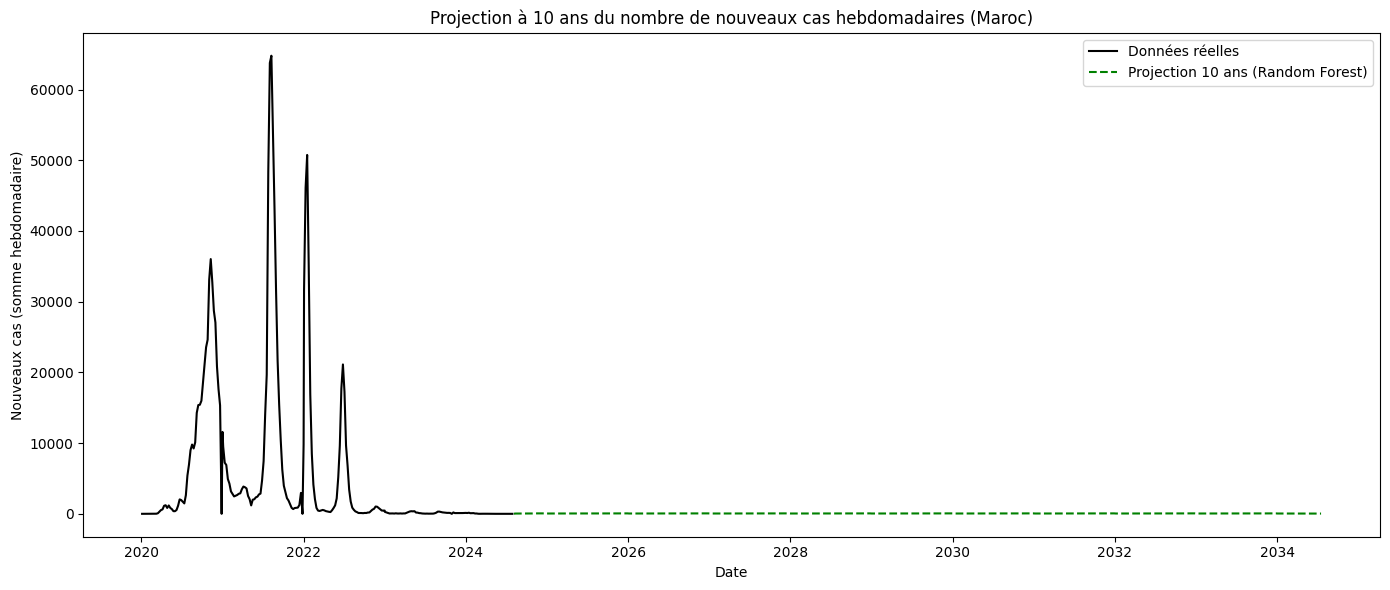

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd # S'assurer que pandas est importé pour pd.to_datetime

plt.figure(figsize=(14, 6))

# Récupérer la date maximale de df_features et la convertir au format pandas datetime
date_max_df_features = pd.to_datetime(df_features.select(spark_max("date")).collect()[0][0])

# Partie réelle
partie_reelle = historique[historique["date"] <= date_max_df_features]
plt.plot(partie_reelle["date"], partie_reelle["new_cases"], label="Données réelles", color="black")

# Partie projetée
partie_projetee = historique[historique["date"] > date_max_df_features]
plt.plot(partie_projetee["date"], partie_projetee["new_cases"], label="Projection 10 ans (Random Forest)", color="green", linestyle="--")

plt.legend()
plt.title("Projection à 10 ans du nombre de nouveaux cas hebdomadaires (Maroc)")
plt.xlabel("Date")
plt.ylabel("Nouveaux cas (somme hebdomadaire)")
plt.tight_layout()
plt.show()

In [ ]:
!pip install prophet -q

In [ ]:
import pandas as pd
import numpy as np

df_prophet = df_features.select("date", "new_cases").orderBy("date").toPandas()
df_prophet = df_prophet.rename(columns={"date": "ds", "new_cases": "y"})

# Transformation logarithmique de la cible (même correction que pour LR/RF)
df_prophet["y"] = np.log1p(df_prophet["y"])

df_prophet.head()

,ds,y
0,2020-01-05,0.0
1,2020-01-06,0.0
2,2020-01-13,0.0
3,2020-01-20,0.0
4,2020-01-27,0.0


In [ ]:
nb_total = len(df_prophet)
nb_train = int(nb_total * 0.8)

df_train_prophet = df_prophet.iloc[:nb_train]
df_test_prophet = df_prophet.iloc[nb_train:]

print("Train :", len(df_train_prophet), " | Test :", len(df_test_prophet))

Train : 192  | Test : 49


In [ ]:
from prophet import Prophet

modele_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,   # déjà agrégé par semaine, pas de saisonnalité intra-semaine à capter
    changepoint_prior_scale=0.05  # plus permissif aux changements de tendance (utile vu la rupture 2022)
)

modele_prophet.fit(df_train_prophet)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future_test = df_test_prophet[["ds"]]
forecast_test = modele_prophet.predict(future_test)

# Reconversion : expm1 pour annuler le log1p appliqué plus haut
forecast_test["yhat_reelle"] = np.expm1(forecast_test["yhat"])
y_reel_test = np.expm1(df_test_prophet["y"].values)

comparaison_test = df_test_prophet[["ds"]].copy()
comparaison_test["y_reel"] = y_reel_test
comparaison_test["yhat_reelle"] = forecast_test["yhat_reelle"].values

comparaison_test.head(10)

,ds,y_reel,yhat_reelle
192,2023-08-21,161.0,256.448683
193,2023-08-28,309.0,207.886868
194,2023-09-04,312.0,160.048234
195,2023-09-11,254.0,134.160944
196,2023-09-18,205.0,120.748466
197,2023-09-25,177.0,103.607043
198,2023-10-02,138.0,82.469746
199,2023-10-09,132.0,70.173528
200,2023-10-16,136.0,73.484753
201,2023-10-23,124.0,88.289957


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

rmse_prophet = np.sqrt(mean_squared_error(comparaison_test["y_reel"], comparaison_test["yhat_reelle"]))
r2_prophet = r2_score(comparaison_test["y_reel"], comparaison_test["yhat_reelle"])

print(f"RMSE Prophet : {rmse_prophet:.2f}")
print(f"R² Prophet   : {r2_prophet:.3f}")

RMSE Prophet : 61.77
R² Prophet   : 0.463


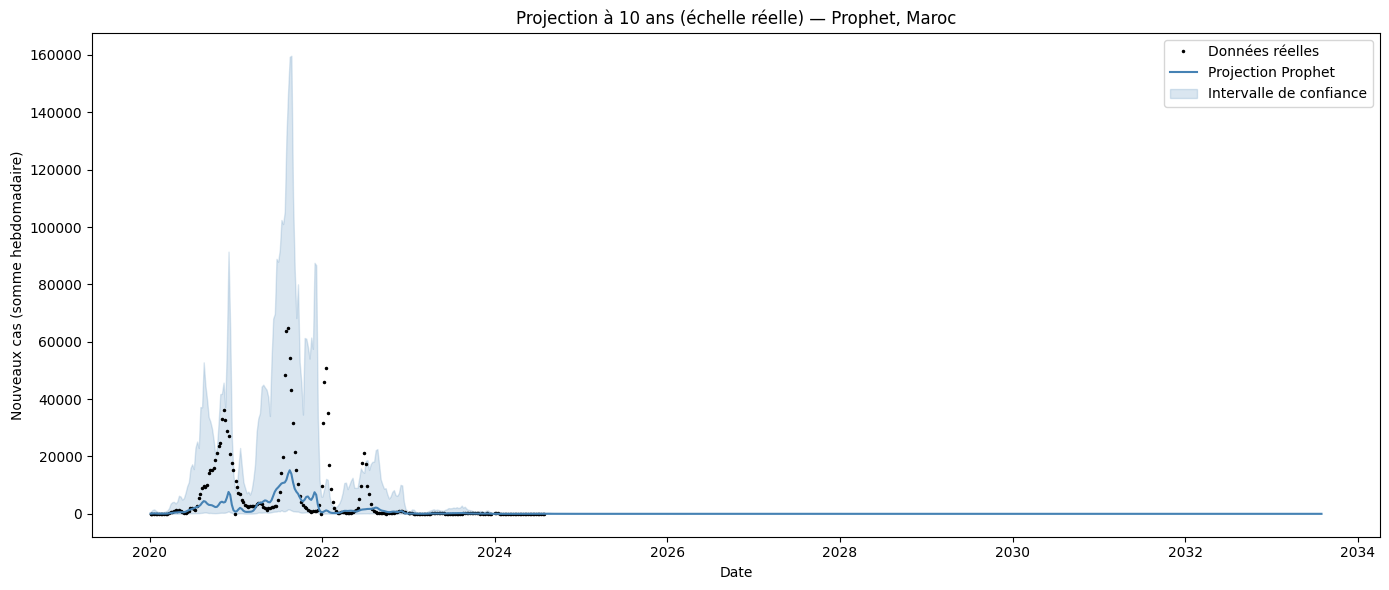

In [ ]:
future_10ans = modele_prophet.make_future_dataframe(periods=520, freq="W")
forecast_10ans = modele_prophet.predict(future_10ans)
forecast_10ans["yhat_reelle"] = np.expm1(forecast_10ans["yhat"])
forecast_10ans["yhat_lower_reelle"] = np.expm1(forecast_10ans["yhat_lower"])
forecast_10ans["yhat_upper_reelle"] = np.expm1(forecast_10ans["yhat_upper"])

# Visualisation native de Prophet (inclut l'incertitude !)
# fig = modele_prophet.plot(forecast_10ans)

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Historique réel (reconversion depuis log)
historique_reel_dates = df_prophet["ds"]
historique_reel_valeurs = np.expm1(df_prophet["y"])
plt.plot(historique_reel_dates, historique_reel_valeurs, "k.", label="Données réelles", markersize=3)

# Projection reconvertie
plt.plot(forecast_10ans["ds"], forecast_10ans["yhat_reelle"], color="steelblue", label="Projection Prophet")
plt.fill_between(
    forecast_10ans["ds"],
    forecast_10ans["yhat_lower_reelle"].clip(lower=0),  # on ne peut pas avoir un nombre de cas négatif
    forecast_10ans["yhat_upper_reelle"],
    color="steelblue", alpha=0.2, label="Intervalle de confiance"
)

plt.legend()
plt.title("Projection à 10 ans (échelle réelle) — Prophet, Maroc")
plt.xlabel("Date")
plt.ylabel("Nouveaux cas (somme hebdomadaire)")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

comparaison_finale = pd.DataFrame({
    "Modèle": ["Régression Linéaire (MLlib)", "Random Forest (MLlib)", "Prophet"],
    "RMSE": [309.23, 70.66, rmse_prophet],
    "R²": [-12.45, 0.30, r2_prophet]
})
print(comparaison_finale)

                        Modèle        RMSE         R²
0  Régression Linéaire (MLlib)  309.230000 -12.450000
1        Random Forest (MLlib)   70.660000   0.300000
2                      Prophet   61.771858   0.463106
